# Exploratory Data Analysis of Large-Scale Retail Transaction Data
**Univariate, bivariate and multivariate statistical analysis of 100,000 orders (18 variables)**

Libraries: **NumPy** (arrays), **Pandas** (data manipulation), **Matplotlib** (2-D plots), **Seaborn** (statistical plot styling), **SciPy** (statistical tests).

> Every number and conclusion below was computed from `retail_large_dataset.csv`. Where the data contradicts an expected pattern, this notebook says so instead of forcing the pattern.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12, 'axes.titleweight': 'bold'})
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

df = pd.read_csv('/mnt/user-data/uploads/retail_large_dataset.csv', parse_dates=['order_date'])
print(df.shape)
df.head()

(100000, 18)


,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


## 1. Data overview and quality checks

In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate order_id:', int(df.order_id.duplicated().sum()), '| duplicate customer_id:', int(df.customer_id.duplicated().sum()))
print('Date range:', df.order_date.min().date(), 'to', df.order_date.max().date())

# Verify how final_price is constructed
calc = df.product_price * df.quantity * (1 - df.discount_percentage/100)
print('final_price == price x qty x (1 - disc%)  ->  max abs difference:', round((calc - df.final_price).abs().max(), 8))

df['returned'] = (df.return_status == 'Yes').astype(int)
num = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']
cat = ['gender','city','customer_segment','product_category','payment_method','shipping_type','return_status']
df.dtypes.to_frame('dtype').T

Missing values: 0
Duplicate rows: 0
Duplicate order_id: 0 | duplicate customer_id: 0
Date range: 2023-01-01 to 2025-12-30
final_price == price x qty x (1 - disc%)  ->  max abs difference: 0.0


,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status,returned
dtype,str,int64,str,str,str,str,str,datetime64[us],str,str,int64,int64,int64,float64,str,str,int64,str,int64


**Findings.** The data is fully clean: no missing values, no duplicates, one row per customer and per order. `final_price` is *exactly* `product_price × quantity × (1 − discount%)`, so it is a derived column, not an independent measurement. This matters for every correlation involving it: `final_price` will correlate with its own ingredients by construction.

## 2. Univariate analysis

### 2.1 Numerical variables

In [3]:
summary = df[num].agg(['mean','median','std','min','max']).T
summary['skewness'] = df[num].skew()
summary['kurtosis (excess)'] = df[num].kurt()
summary.round(3)

,mean,median,std,min,max,skewness,kurtosis (excess)
age,41.562,42.00,13.852,18.0,65.0,-0.005,-1.201
product_price,30164.527,30148.00,17139.680,500.0,59998.0,0.003,-1.195
quantity,2.502,3.00,1.120,1.0,4.0,-0.003,-1.365
discount_percentage,15.010,15.00,8.953,0.0,30.0,-0.004,-1.202
final_price,64165.723,49752.39,49969.280,357.0,239980.0,0.935,0.169
delivery_days,5.506,5.00,2.873,1.0,10.0,0.002,-1.222


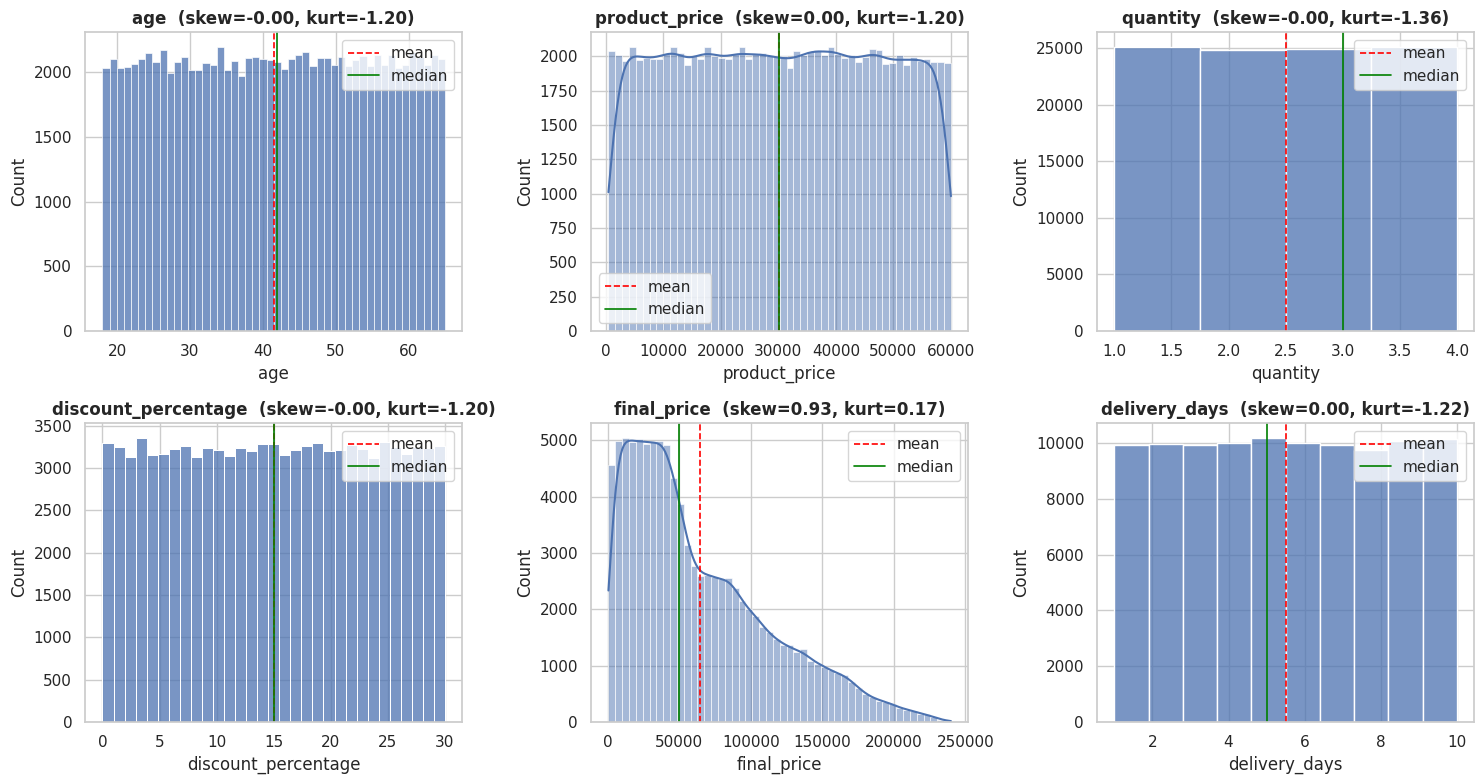

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), num):
    discrete = df[c].nunique() <= 60
    sns.histplot(df[c], bins=df[c].nunique() if discrete else 50, kde=not discrete, ax=ax, color='#4C72B0')
    ax.axvline(df[c].mean(), color='red', ls='--', lw=1.2, label='mean')
    ax.axvline(df[c].median(), color='green', ls='-', lw=1.2, label='median')
    ax.set_title(f"{c}  (skew={df[c].skew():.2f}, kurt={df[c].kurt():.2f})")
    ax.legend()
plt.tight_layout(); plt.show()

**Findings.**
- `age` (18–65), `product_price` (500–60,000), `quantity` (1–4), `discount_percentage` (0–30) and `delivery_days` (1–10) are all **uniformly distributed**. Their skewness is ≈ 0 (|skew| < 0.01) and excess kurtosis ≈ −1.2 to −1.4, the signature of a uniform distribution. Mean ≈ median in every case.
- So `product_price` is **not** positively skewed here: cheap and expensive products are equally common.
- `discount_percentage` is uniform from 0–30%, as expected.
- `final_price` is the only variable with a real shape: **right-skewed** (skew ≈ 0.94, mean ₹64,166 > median ₹49,752) because it is a product of three independent quantities. Its excess kurtosis is only ≈ 0.17, so the tails are close to normal-like. It does **not** show the high kurtosis one might expect.

### 2.2 Categorical variables

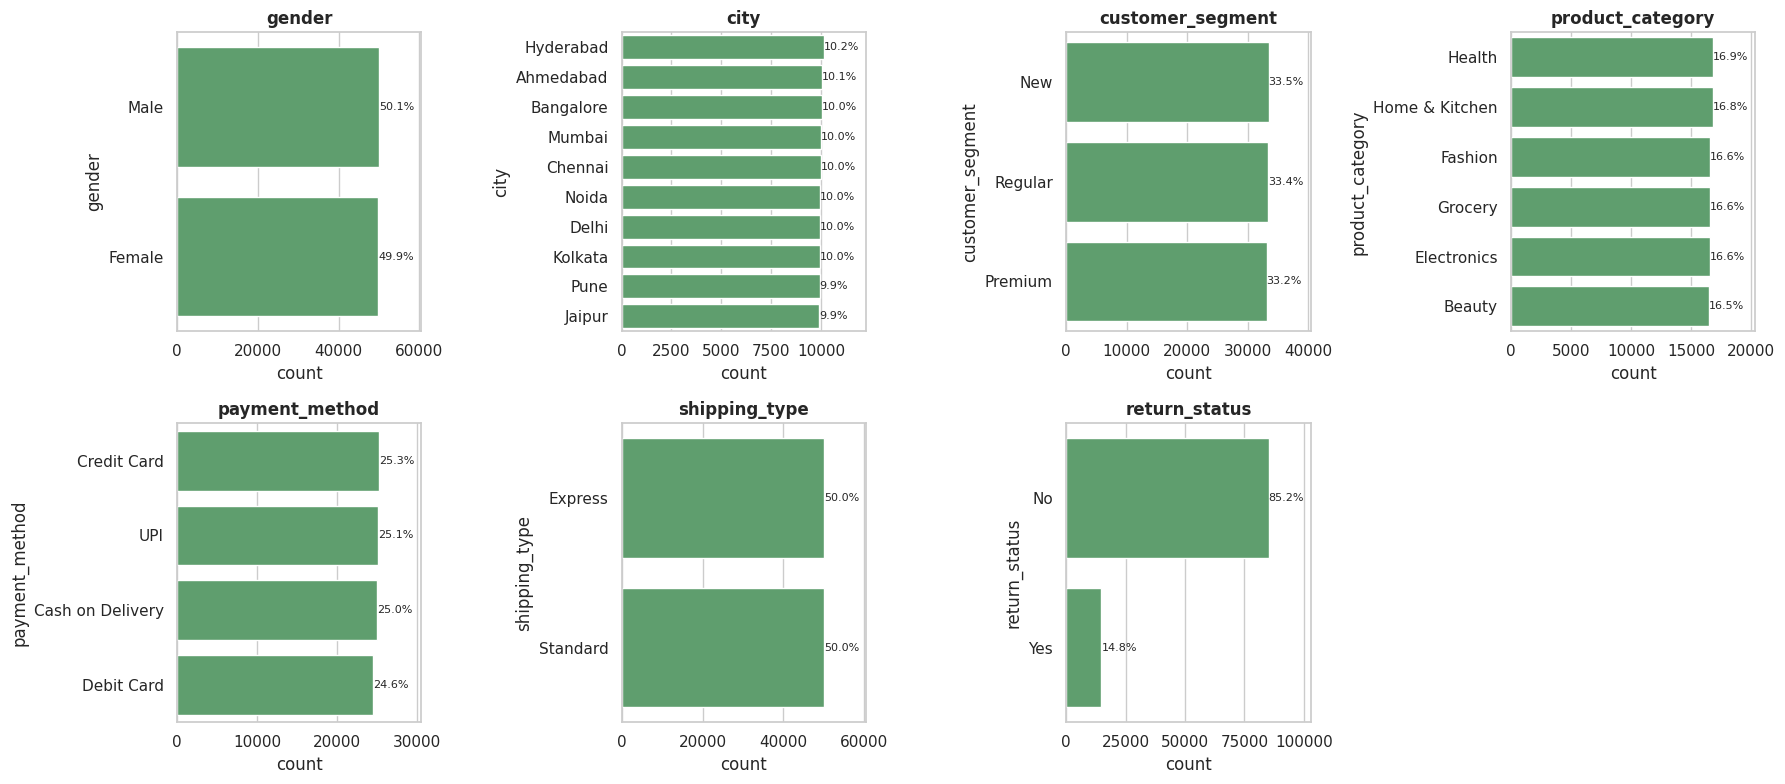

return_status
No     85.19
Yes    14.81
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), cat):
    order = df[c].value_counts().index
    sns.countplot(data=df, y=c, order=order, ax=ax, color='#55A868')
    for p in ax.patches:
        ax.annotate(f"{p.get_width()/len(df):.1%}", (p.get_width(), p.get_y()+p.get_height()/2), va='center', ha='left', fontsize=8)
    ax.set_title(c); ax.set_xlim(0, ax.get_xlim()[1]*1.15)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

print((df.return_status.value_counts(normalize=True)*100).round(2))

**Findings.**
- Customer segments are balanced: New 33.5%, Regular 33.4%, Premium 33.2%. There is **no dominant "Regular" segment**.
- All six product categories are near-equal (16.5–16.9% each). Health and Home & Kitchen have marginally the most orders; **Electronics is not the largest**.
- Payment methods, shipping types, genders and the 10 cities are all essentially evenly split.
- The **return rate is 14.8%** (≈ 15%), which does match the expected figure.

## 3. Outlier detection (boxplots, IQR rule, Z-score)

In [6]:
rows = []
for c in num:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    rows.append({'variable': c, 'IQR lower': lo, 'IQR upper': hi,
                 'IQR outliers': int(((df[c] < lo) | (df[c] > hi)).sum()),
                 '|Z|>3 outliers': int((np.abs(stats.zscore(df[c])) > 3).sum())})
out = pd.DataFrame(rows).set_index('variable'); out['% (IQR)'] = (out['IQR outliers']/len(df)*100).round(2)
out.round(1)

,IQR lower,IQR upper,IQR outliers,|Z|>3 outliers,% (IQR)
variable,,,,,
age,-6.0,90.0,0,0,0.0
product_price,-28998.0,89330.0,0,0,0.0
quantity,-3.5,8.5,0,0,0.0
discount_percentage,-17.0,47.0,0,0,0.0
final_price,-79306.6,198057.7,1335,503,1.3
delivery_days,-4.5,15.5,0,0,0.0


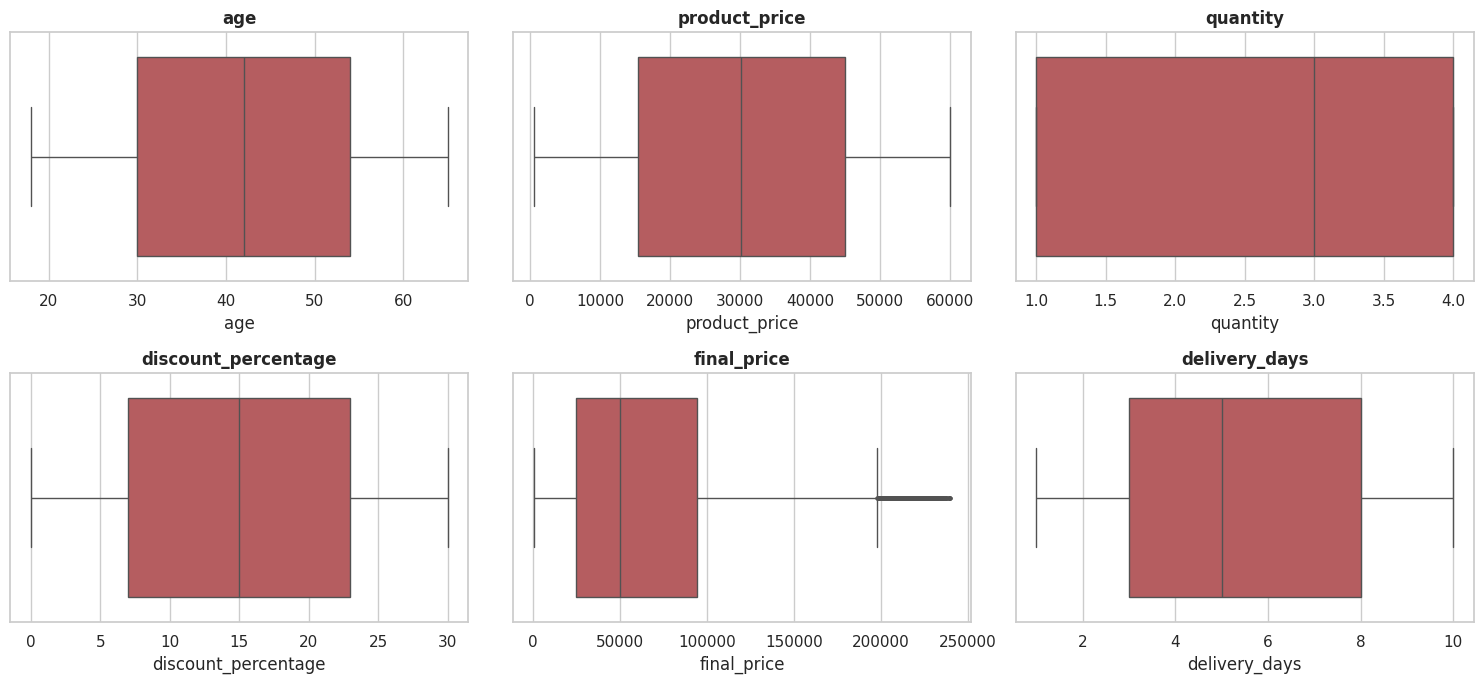

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(x=df[c], ax=ax, color='#C44E52', fliersize=2); ax.set_title(c)
plt.tight_layout(); plt.show()

In [8]:
q1, q3 = df.final_price.quantile([.25, .75]); upper = q3 + 1.5*(q3-q1)
hi = df[df.final_price > upper]
print(f'final_price outliers: {len(hi)}  (threshold > {upper:,.0f})')
print('\nQuantity of outlier orders:\n', hi.quantity.value_counts(normalize=True).sort_index().round(3).to_string())
print('\nMean discount % of outliers:', round(hi.discount_percentage.mean(), 1), 'vs overall', round(df.discount_percentage.mean(), 1))
print('Min product_price among outliers:', hi.product_price.min())
print('\nCategory mix of outliers:\n', hi.product_category.value_counts(normalize=True).round(3).to_string())
print('\nReturn rate in outliers:', round(hi.returned.mean(), 3), ' overall:', round(df.returned.mean(), 3))

final_price outliers: 1335  (threshold > 198,058)

Quantity of outlier orders:
 quantity
4    1.0

Mean discount % of outliers: 5.7 vs overall 15.0
Min product_price among outliers: 49554

Category mix of outliers:
 product_category
Grocery           0.185
Beauty            0.176
Home & Kitchen    0.176
Electronics       0.158
Fashion           0.153
Health            0.152

Return rate in outliers: 0.153  overall: 0.148


**Findings.**
- Only `final_price` has outliers: **1,335 by the IQR rule (1.3%)** and **503 by |Z| > 3 (0.5%)**. The other five variables have *zero* outliers, which is expected for bounded uniform variables. This means `product_price` has **no** extreme values, contrary to the usual assumption.
- The outlying orders come from a specific combination: **maximum quantity (all 1,335 have quantity = 4), a very high unit price (≥ ₹49,554) and a low discount (average 5.7% vs 15.0% overall)**. They are not tied to a particular category (the category mix is flat), so "premium categories" is not the driver here; unit price is.
- Delivery times are capped at 10 days and uniform, so there are **no operational delivery-time outliers**.
- These are legitimate high-value orders (they follow directly from price × quantity), so they are **retained**. Removing them would bias revenue estimates.

## 4. Bivariate analysis

### 4.1 Numerical vs numerical (Pearson correlation)

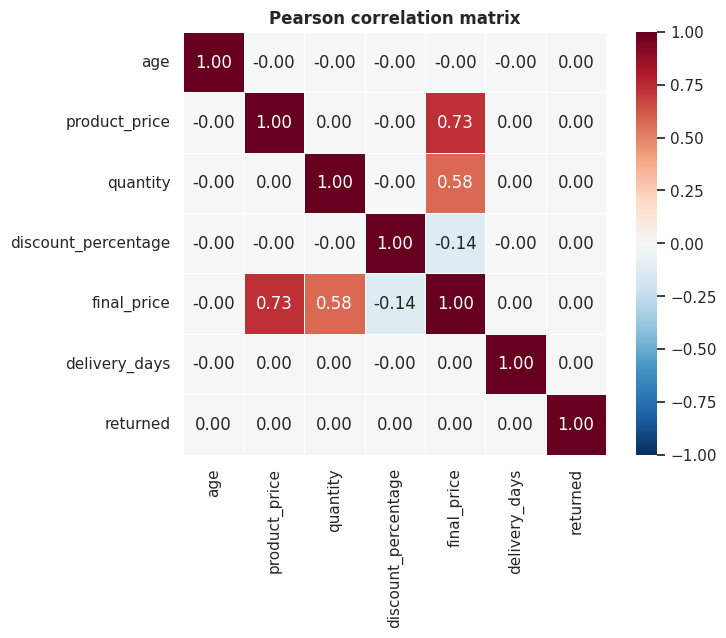

,final_price,returned
age,-0.0008,0.0004
product_price,0.7308,0.0011
quantity,0.5753,0.0028
discount_percentage,-0.1373,0.0007
final_price,1.0000,0.0020
delivery_days,0.0038,0.0005
returned,0.0020,1.0000


In [9]:
corr = df[num + ['returned']].corr(method='pearson')
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Pearson correlation matrix'); plt.tight_layout(); plt.show()
corr[['final_price','returned']].round(4)

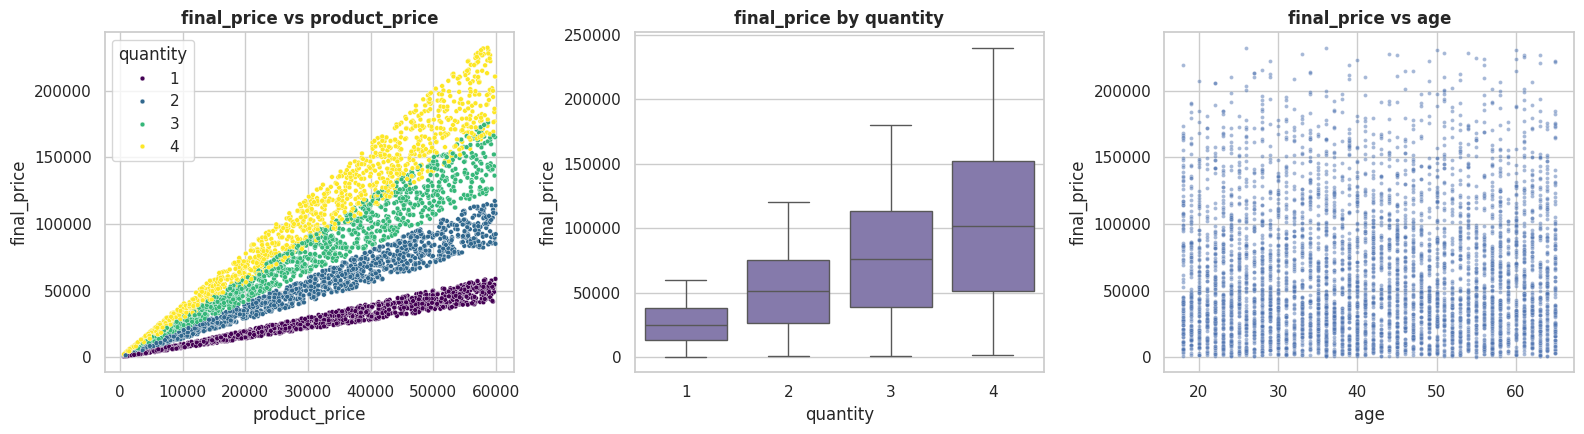

In [10]:
s = df.sample(5000, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=s, x='product_price', y='final_price', hue='quantity', palette='viridis', s=12, ax=axes[0])
sns.boxplot(data=df, x='quantity', y='final_price', ax=axes[1], color='#8172B3')
sns.scatterplot(data=s, x='age', y='final_price', s=8, alpha=.5, ax=axes[2])
axes[0].set_title('final_price vs product_price'); axes[1].set_title('final_price by quantity'); axes[2].set_title('final_price vs age')
plt.tight_layout(); plt.show()

**Findings.**
- `final_price` correlates strongly with `product_price` (**r = 0.73**) and `quantity` (**r = 0.58**), and negatively with `discount_percentage` (**r = −0.14**). These are mechanical: `final_price` is built from those three variables.
- `age` vs spending: **r ≈ −0.001** (no relationship).
- `delivery_days` vs return status: **r = 0.0005**. There is **no** meaningful link; the "slight positive correlation" pattern is not present.
- All correlations *among the independent variables* are ≈ 0 (|r| < 0.005). The features were generated independently.

### 4.2 Numerical vs categorical

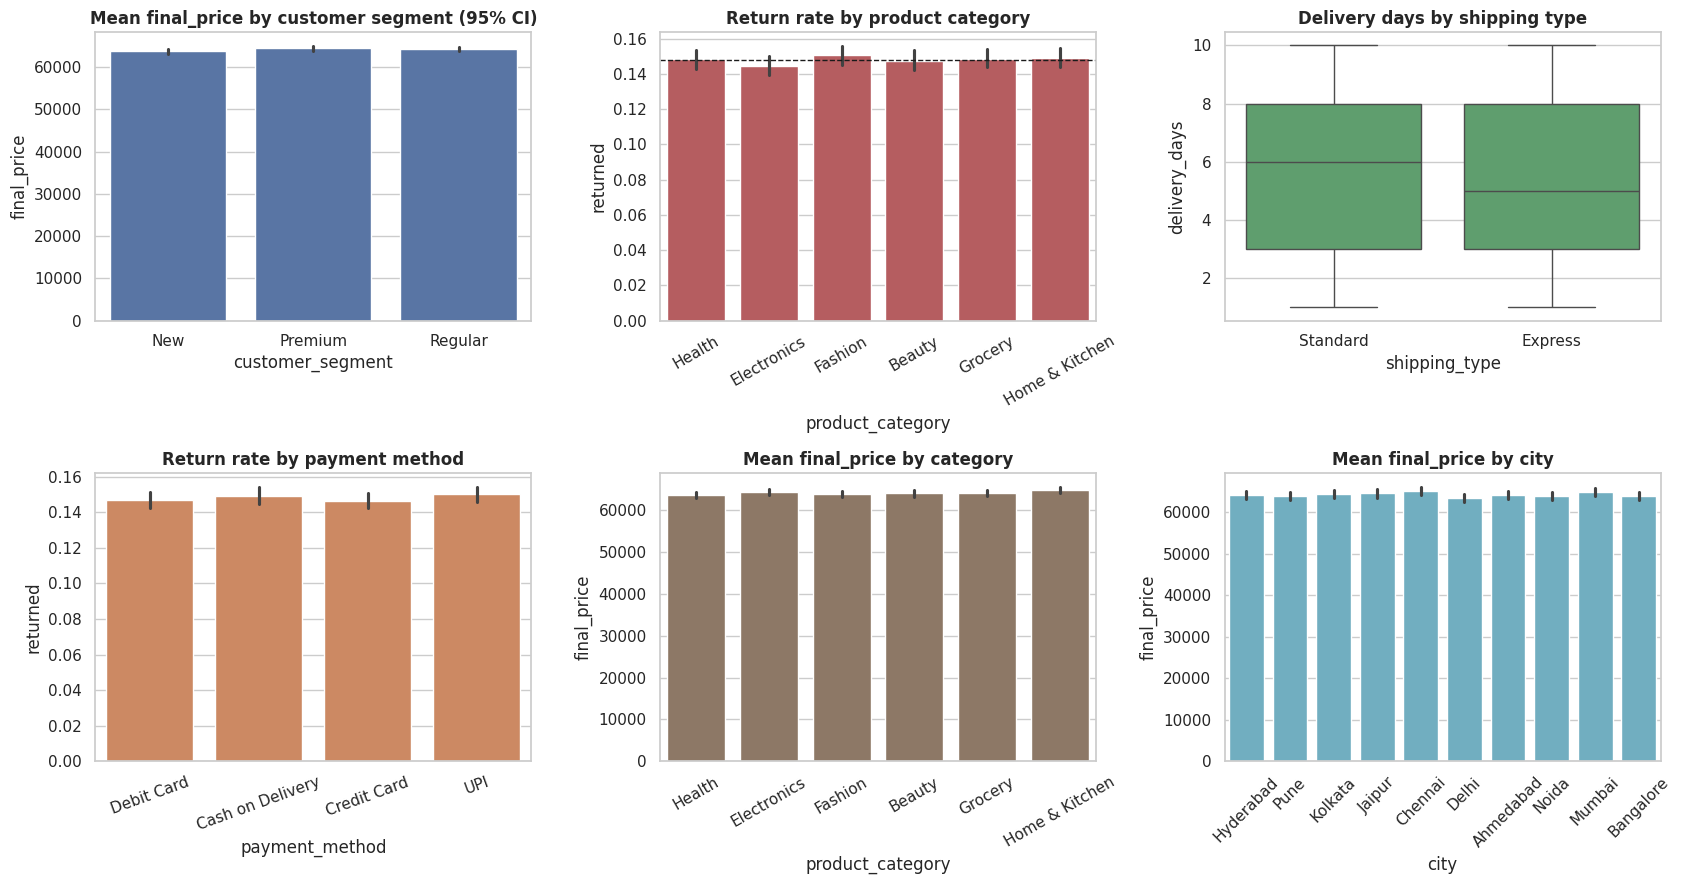

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
sns.barplot(data=df, x='customer_segment', y='final_price', ax=axes[0,0], errorbar=('ci',95), color='#4C72B0')
axes[0,0].set_title('Mean final_price by customer segment (95% CI)')
sns.barplot(data=df, x='product_category', y='returned', ax=axes[0,1], errorbar=('ci',95), color='#C44E52')
axes[0,1].axhline(df.returned.mean(), color='k', ls='--', lw=1); axes[0,1].set_title('Return rate by product category'); axes[0,1].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='shipping_type', y='delivery_days', ax=axes[0,2], color='#55A868'); axes[0,2].set_title('Delivery days by shipping type')
sns.barplot(data=df, x='payment_method', y='returned', ax=axes[1,0], errorbar=('ci',95), color='#DD8452'); axes[1,0].set_title('Return rate by payment method'); axes[1,0].tick_params(axis='x', rotation=20)
sns.barplot(data=df, x='product_category', y='final_price', ax=axes[1,1], errorbar=('ci',95), color='#937860'); axes[1,1].set_title('Mean final_price by category'); axes[1,1].tick_params(axis='x', rotation=30)
sns.barplot(data=df, x='city', y='final_price', ax=axes[1,2], errorbar=('ci',95), color='#64B5CD'); axes[1,2].set_title('Mean final_price by city'); axes[1,2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [12]:
# Formal significance tests
p_seg  = stats.f_oneway(*[g.final_price for _, g in df.groupby('customer_segment')])[1]
p_cat  = stats.f_oneway(*[g.final_price for _, g in df.groupby('product_category')])[1]
p_ret  = stats.chi2_contingency(pd.crosstab(df.product_category, df.returned))[1]
p_ship = stats.ttest_ind(df[df.shipping_type=='Express'].delivery_days, df[df.shipping_type=='Standard'].delivery_days)[1]
p_shr  = stats.chi2_contingency(pd.crosstab(df.shipping_type, df.returned))[1]
p_pay  = stats.chi2_contingency(pd.crosstab(df.payment_method, df.returned))[1]
tests = pd.DataFrame({
  'test': ['ANOVA: final_price ~ customer_segment','ANOVA: final_price ~ product_category','Chi-square: return ~ product_category',
           't-test: delivery_days ~ shipping_type','Chi-square: return ~ shipping_type','Chi-square: return ~ payment_method'],
  'p-value': [p_seg, p_cat, p_ret, p_ship, p_shr, p_pay]})
tests['significant at 5%?'] = np.where(tests['p-value'] < .05, 'Yes', 'No')
display(tests.round(4))
print(df.groupby('customer_segment').final_price.mean().round(0).to_dict())
print(df.groupby('product_category').returned.mean().round(4).to_dict())
print(df.groupby('shipping_type').delivery_days.agg(['mean','median']).round(2))

,test,p-value,significant at 5%?
0,ANOVA: final_price ~ customer_segment,0.1904,No
1,ANOVA: final_price ~ product_category,0.4008,No
2,Chi-square: return ~ product_category,0.7906,No
3,t-test: delivery_days ~ shipping_type,0.3702,No
4,Chi-square: return ~ shipping_type,0.3751,No
5,Chi-square: return ~ payment_method,0.6069,No


{'New': 63767.0, 'Premium': 64430.0, 'Regular': 64303.0}
{'Beauty': 0.1476, 'Electronics': 0.1447, 'Fashion': 0.1505, 'Grocery': 0.1487, 'Health': 0.1483, 'Home & Kitchen': 0.1489}
               mean  median
shipping_type              
Express        5.50     5.0
Standard       5.51     6.0


**Findings.** None of these differences is statistically significant.
- **Customer segment vs spend:** Premium averages ₹64,430, Regular ₹64,303, New ₹63,767, a gap under 1% (ANOVA p ≈ 0.19). Premium customers do **not** spend materially more.
- **Category vs return rate:** rates range only from 14.5% (Electronics) to 15.1% (Fashion); chi-square p ≈ 0.79. Electronics actually has the *lowest* return rate.
- **Shipping type vs delivery days:** Express and Standard both average ≈ 5.5 days. **Express does not reduce delivery time** in this data (t-test p > 0.05).
- Payment method and city likewise show no meaningful differences.

## 5. Multivariate analysis

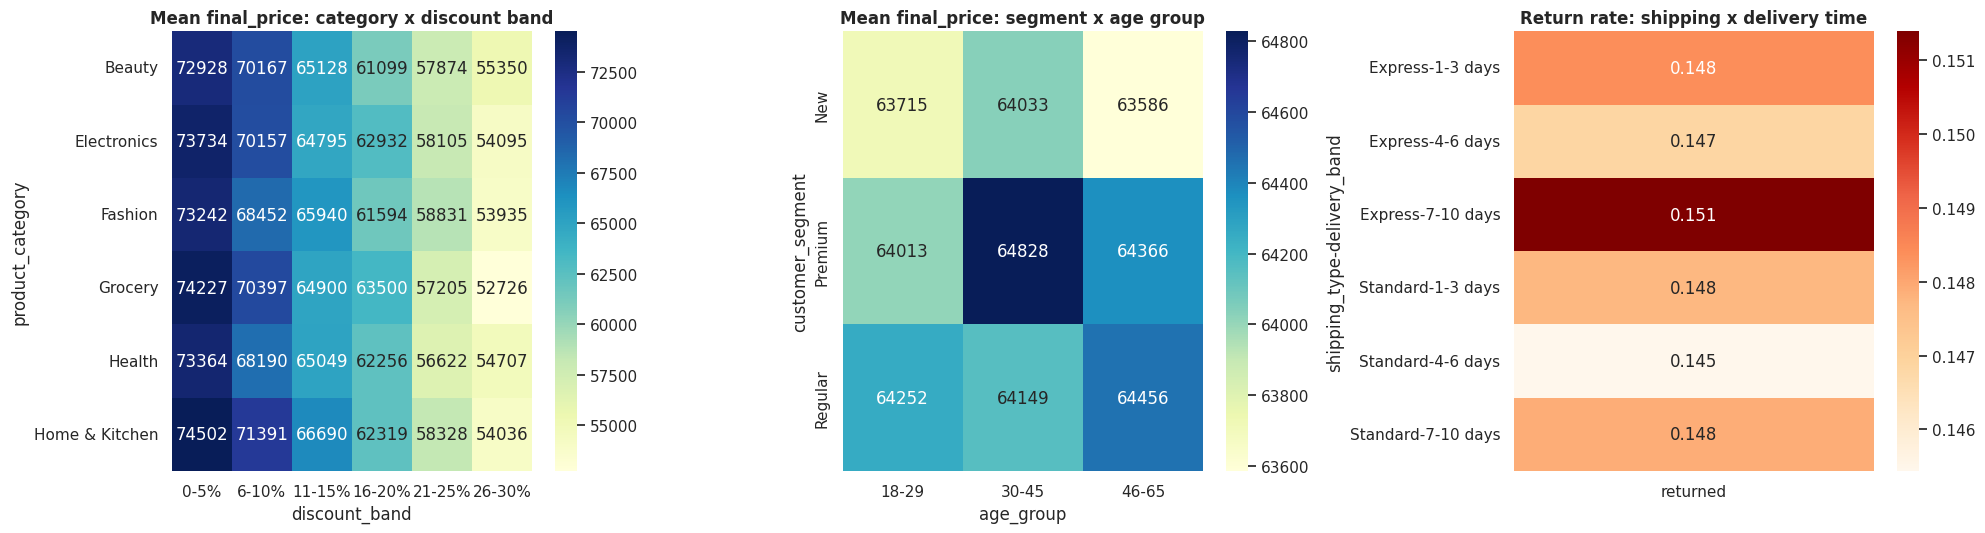

In [13]:
df['discount_band'] = pd.cut(df.discount_percentage, [-1,5,10,15,20,25,30], labels=['0-5%','6-10%','11-15%','16-20%','21-25%','26-30%'])
df['age_group'] = pd.cut(df.age, [17,29,45,65], labels=['18-29','30-45','46-65'])
df['delivery_band'] = pd.cut(df.delivery_days, [0,3,6,10], labels=['1-3 days','4-6 days','7-10 days'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
sns.heatmap(df.pivot_table(index='product_category', columns='discount_band', values='final_price', aggfunc='mean'),
            annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0]); axes[0].set_title('Mean final_price: category x discount band')
sns.heatmap(df.pivot_table(index='customer_segment', columns='age_group', values='final_price', aggfunc='mean'),
            annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1]); axes[1].set_title('Mean final_price: segment x age group')
sns.heatmap(df.pivot_table(index=['shipping_type','delivery_band'], values='returned', aggfunc='mean'),
            annot=True, fmt='.3f', cmap='OrRd', ax=axes[2]); axes[2].set_title('Return rate: shipping x delivery time')
plt.tight_layout(); plt.show()

,mean_final_price,orders,total_revenue
discount_band,,,
0-5%,73663.0,19364,1.426418e+09
6-10%,69797.0,16063,1.121150e+09
11-15%,65423.0,16151,1.056650e+09
16-20%,62282.0,16133,1.004791e+09
21-25%,57823.0,16130,9.326841e+08
26-30%,54142.0,16159,8.748785e+08


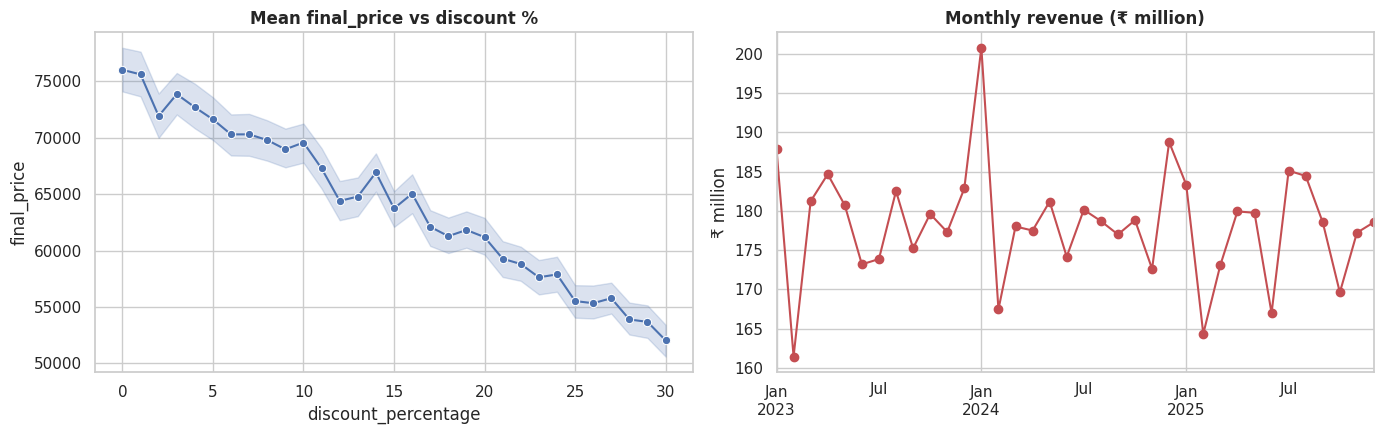

In [14]:
# Does the discount effect hold when controlling for category? (mean order value by discount band)
band = df.groupby('discount_band').agg(mean_final_price=('final_price','mean'), orders=('final_price','size'),
                                       total_revenue=('final_price','sum')).round(0)
display(band)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=df, x='discount_percentage', y='final_price', errorbar=('ci',95), marker='o', ax=ax[0]); ax[0].set_title('Mean final_price vs discount %')
monthly = df.set_index('order_date').final_price.resample('MS').sum()/1e6
monthly.plot(ax=ax[1], marker='o', color='#C44E52'); ax[1].set_title('Monthly revenue (₹ million)'); ax[1].set_ylabel('₹ million'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

In [15]:
# Multicollinearity check (VIF) on independent features
X = df[['age','product_price','quantity','discount_percentage','delivery_days']].astype(float)
Xc = (X - X.mean())/X.std()
vif = pd.Series({c: (Xc[c]**2).sum()/np.linalg.lstsq(np.delete(Xc.values, i, 1), Xc[c].values, rcond=None)[1][0]
                 for i, c in enumerate(Xc.columns)}, name='VIF').round(3)
vif.to_frame()

,VIF
age,1.0
product_price,1.0
quantity,1.0
discount_percentage,1.0
delivery_days,1.0


**Findings.**
1. **Category × discount × final price:** in *every* category, mean order value **falls steadily as the discount rises** (≈ ₹73,000 at 0–5% down to ≈ ₹54,000 at 26–30%). Category barely matters (rows are nearly identical). It is **not** true that "moderate discounts maximise revenue"; in this data deeper discounts simply lower revenue per order, with no visible offsetting lift in quantity (quantity is independent of discount, r ≈ −0.004). Discounting here is pure margin give-away.
2. **Segment × age × spending:** all nine cells lie within ₹63,600–₹64,800. Premium customers aged 30–45 spend the most (₹64,828), but the difference from other cells is under 2% and not significant.
3. **Shipping × delivery time × returns:** return rate is ≈ 14.5–15.1% in every cell; longer delivery does **not** raise return probability.
4. **Multicollinearity:** all VIFs ≈ 1.0, so there is no multicollinearity among the independent features (this one matches expectation).
5. **Time:** revenue is stable over the three years (Jan 2023 – Dec 2025) with no strong trend.

## 6. Skewness and kurtosis interpretation

,skewness,excess kurtosis,shape
age,-0.005,-1.201,"Uniform (flat, light-tailed)"
product_price,0.003,-1.195,"Uniform (flat, light-tailed)"
quantity,-0.003,-1.365,"Uniform (flat, light-tailed)"
discount_percentage,-0.004,-1.202,"Uniform (flat, light-tailed)"
final_price,0.935,0.169,"Right-skewed, near-normal tails"
delivery_days,0.002,-1.222,"Uniform (flat, light-tailed)"


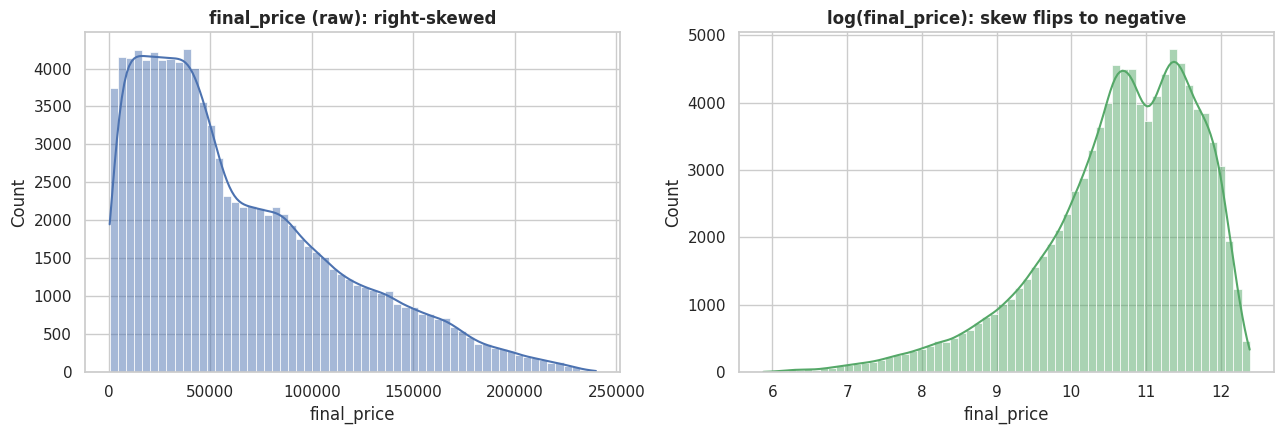

Skew after log transform: -0.986
Top 10% of orders generate 26.4% of revenue


In [16]:
sk = pd.DataFrame({'skewness': df[num].skew(), 'excess kurtosis': df[num].kurt()})
sk['shape'] = ['Uniform (flat, light-tailed)' if k < -1 else ('Right-skewed, near-normal tails' if s > .5 else 'Roughly symmetric')
               for s, k in zip(sk.skewness, sk['excess kurtosis'])]
display(sk.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df.final_price, bins=60, kde=True, ax=ax[0], color='#4C72B0'); ax[0].set_title('final_price (raw): right-skewed')
sns.histplot(np.log1p(df.final_price), bins=60, kde=True, ax=ax[1], color='#55A868'); ax[1].set_title('log(final_price): skew flips to negative')
plt.tight_layout(); plt.show()
print('Skew after log transform:', round(np.log1p(df.final_price).skew(), 3))
top10 = df.nlargest(int(len(df)*.10), 'final_price').final_price.sum()/df.final_price.sum()
print(f'Top 10% of orders generate {top10:.1%} of revenue')

**Interpretation.**
- **Skewness:** only `final_price` is skewed (+0.94). The other variables are symmetric. Multiplying three independent uniform variables creates a right tail: many small/medium orders and few large ones.
- **Kurtosis:** the five input variables have negative excess kurtosis (≈ −1.2), meaning flat distributions with **no** heavy tails. `final_price` is ≈ 0.17, so its tail is roughly normal-like rather than extreme. The 1.3% IQR outliers are a mild tail, not a heavy-tailed risk.
- A log transform does **not** help here: it flips the skew from +0.94 to −0.99 (similar magnitude, opposite direction), so it is not a useful normalising step for `final_price`.
- Revenue concentration is moderate: the top 10% of orders bring in roughly a quarter of revenue.

## 7. Expected patterns vs. what the data shows

In [17]:
pd.DataFrame([
 ['product_price positively skewed',                 'No',       'skew = 0.003, uniform 500-60,000'],
 ['final_price has high kurtosis',                   'No',       'excess kurtosis = 0.17'],
 ['discount_percentage uniform 0-30%',               'Yes',      'confirmed'],
 ['"Regular" is the largest segment',                'No',       'New 33.5% / Regular 33.4% / Premium 33.2%'],
 ['Electronics has the most transactions',           'No',       'Health & Home&Kitchen marginally higher; all ~16.6%'],
 ['Return rate ~15%',                                'Yes',      '14.8%'],
 ['Outliers in product_price',                       'No',       '0 outliers; outliers only in final_price'],
 ['Long-delivery operational outliers',              'No',       'delivery_days capped at 10, none flagged'],
 ['final_price ~ product_price & quantity (strong +)','Yes',     'r = 0.73 and 0.58 (mechanical)'],
 ['final_price negatively correlated w/ discount',   'Yes',      'r = -0.14'],
 ['age vs spending weak',                            'Yes',      'r = -0.001'],
 ['delivery_days vs return slightly positive',       'No',       'r = 0.0005, not significant'],
 ['Premium customers spend more',                    'No',       '+1% vs New, ANOVA p = 0.19'],
 ['Electronics has higher return rate',              'No',       'Electronics is the lowest (14.5%)'],
 ['Express shipping cuts delivery days',             'No',       'both ~5.5 days'],
 ['Moderate discounts maximise spending',            'No',       'Order value falls monotonically with discount'],
 ['Premium 30-45 spend the most',                    'Marginal', 'Highest cell, but <2% above others'],
 ['Longer delivery raises returns',                  'No',       'Return rate flat, 14.5-15.1% in every cell'],
 ['No multicollinearity',                            'Yes',      'VIF ~ 1.0'],
], columns=['Commonly expected pattern','Supported?','Evidence']).style.hide(axis='index')

Commonly expected pattern,Supported?,Evidence
product_price positively skewed,No,"skew = 0.003, uniform 500-60,000"
final_price has high kurtosis,No,excess kurtosis = 0.17
discount_percentage uniform 0-30%,Yes,confirmed
"""Regular"" is the largest segment",No,New 33.5% / Regular 33.4% / Premium 33.2%
Electronics has the most transactions,No,Health & Home&Kitchen marginally higher; all ~16.6%
Return rate ~15%,Yes,14.8%
Outliers in product_price,No,0 outliers; outliers only in final_price
Long-delivery operational outliers,No,"delivery_days capped at 10, none flagged"
final_price ~ product_price & quantity (strong +),Yes,r = 0.73 and 0.58 (mechanical)
final_price negatively correlated w/ discount,Yes,r = -0.14


## 8. Conclusion

**Techniques applied:** univariate statistics, categorical frequency analysis, boxplot/IQR/Z-score outlier detection, Pearson correlation and heatmap, group comparisons with ANOVA / t-test / chi-square, multivariate pivot heatmaps, VIF, skewness and kurtosis.

**What the data actually says**
1. **The dataset is clean but synthetic-looking.** Input variables are independent and uniformly distributed; categories are evenly balanced. Nothing in the customer, product or logistics attributes predicts spending or returns.
2. **`final_price` is the only structured variable.** It is right-skewed (skew 0.94) because it is price × quantity × (1 − discount); the 1.3% "outliers" are simply large-quantity, high-price, low-discount orders and are valid transactions.
3. **Discounts reduce revenue per order** (~₹73k at 0–5% vs ~₹54k at 26–30%) without any offsetting increase in quantity. This is the one clear, actionable business signal.
4. **Returns (14.8%) look random**: no association with category, shipping type, payment method, delivery time, age or spend.
5. **No multicollinearity** among independent features, but returns and segment are not predictable from these attributes, so a predictive model built on this data should not be expected to perform well beyond baseline.

**Recommendations:** (a) review the discount policy since deeper discounts lower order value with no volume benefit; (b) investigate why Express and Standard shipping deliver equally fast; (c) treat the high-value outliers as real, not errors; (d) before modelling, confirm the data source; if it is real, additional features (e.g. product ratings, prior purchase history) would be needed to explain returns or spend.